# Basics of quantum information - Single Systems
Ref: https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/introduction

In [2]:
# %pip install -r requirements.txt

In [1]:
from qiskit import __version__

print(__version__)

2.4.1


In [3]:
from IPython.display import Image, display, Math
from qiskit.visualization import array_to_latex

### Quantum computing = vectors (states) + matrices (gates) + inner products (measurement)

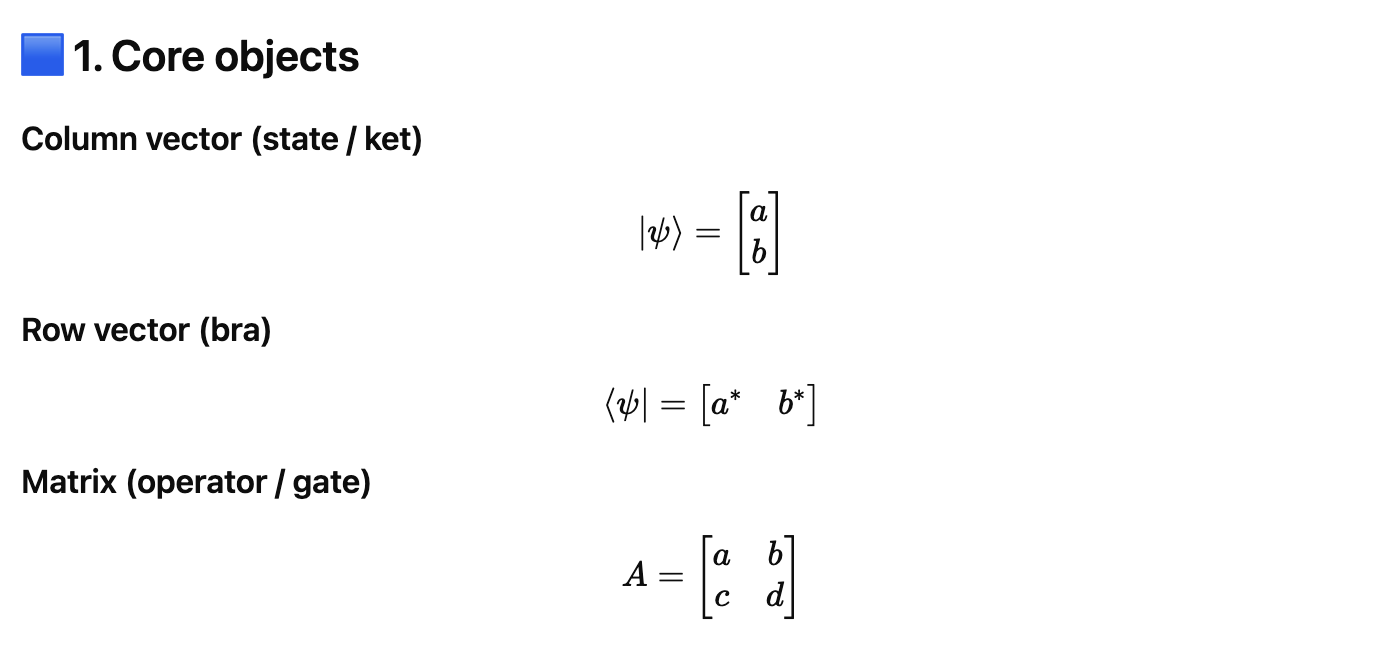

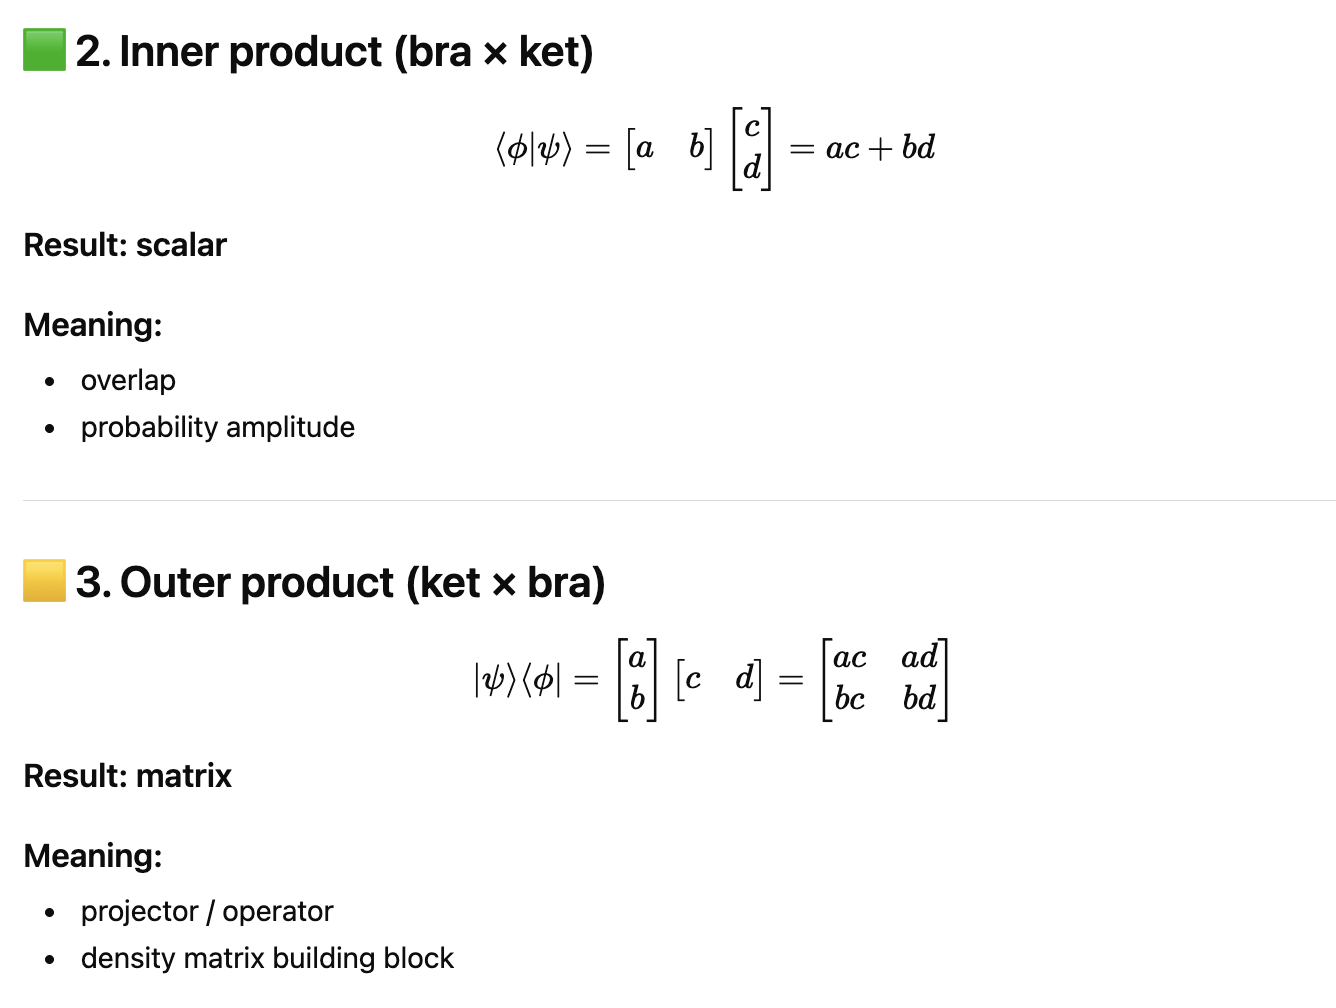

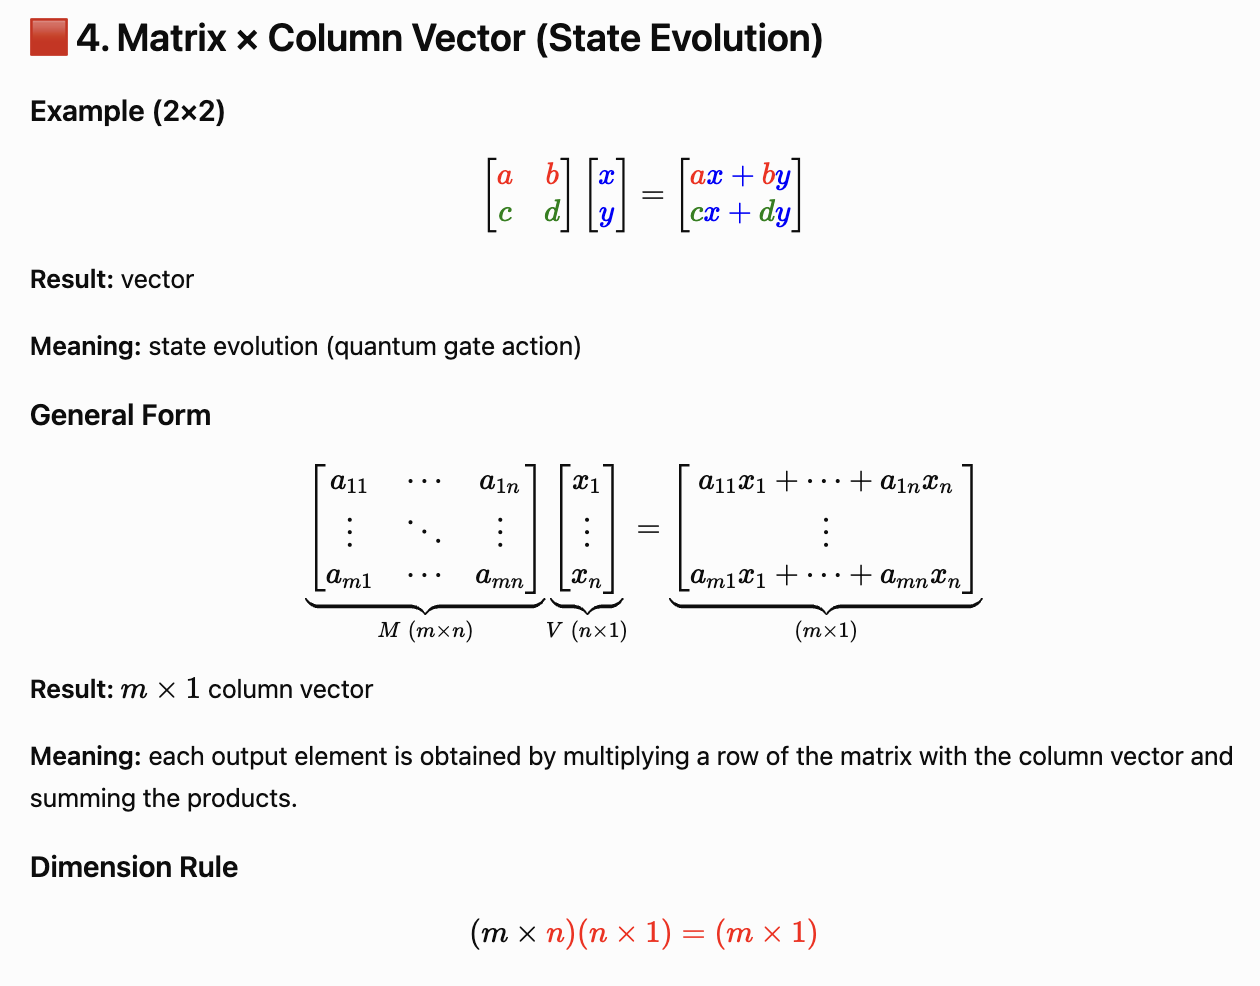

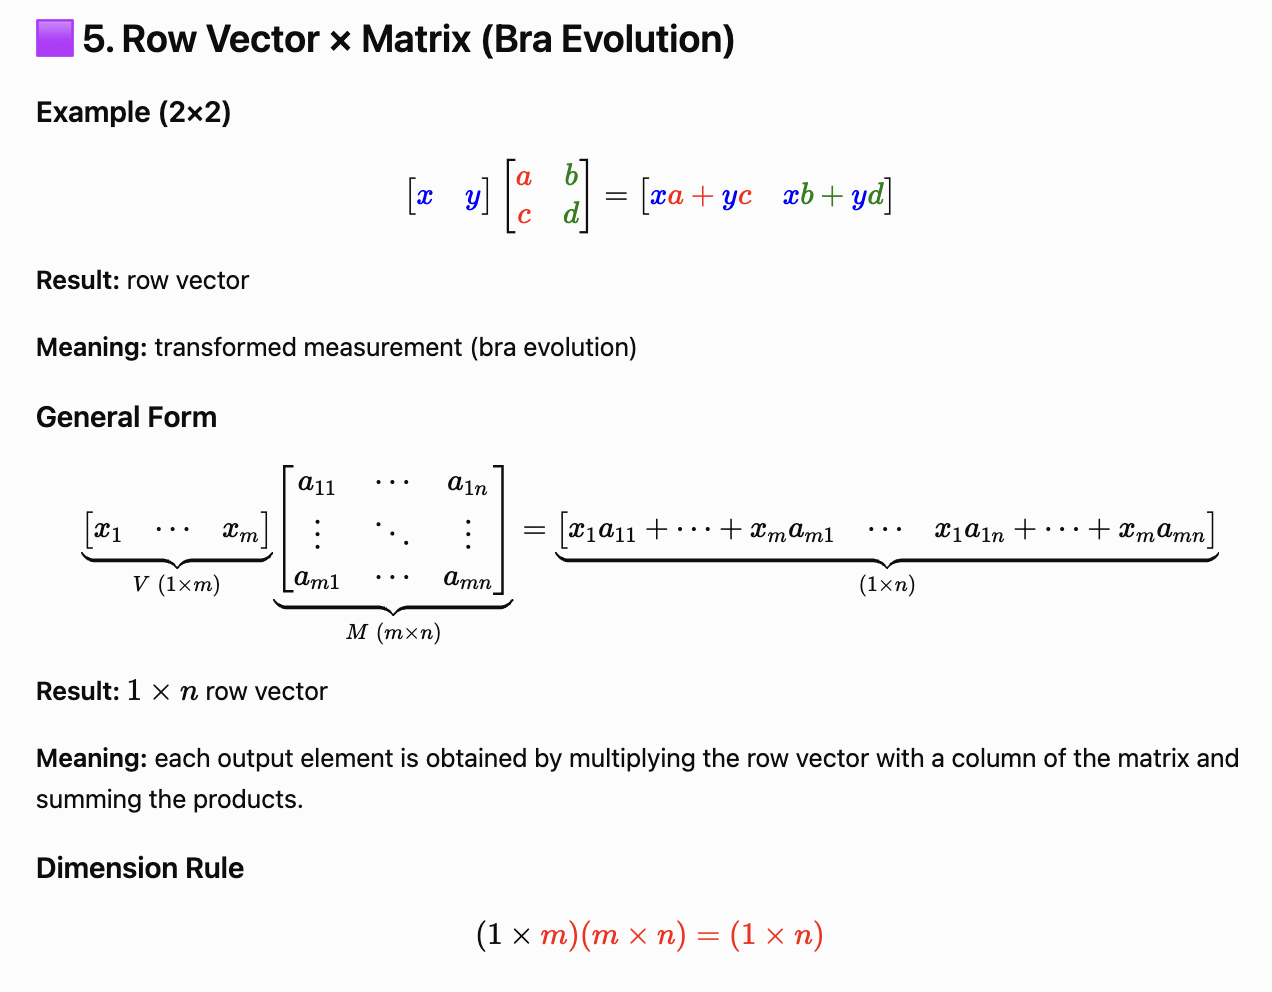

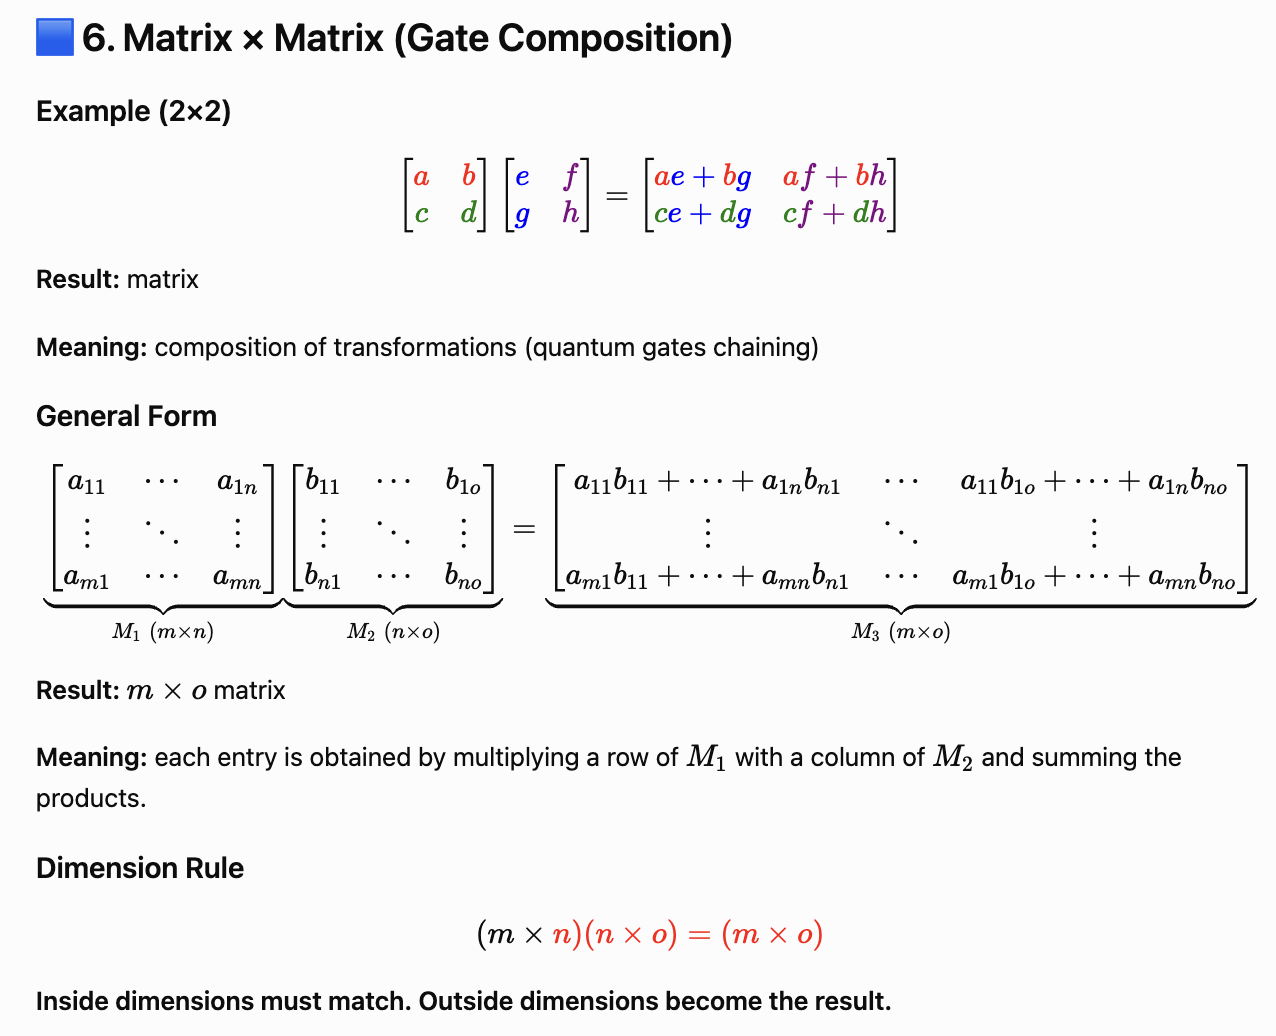

In [30]:
display(Image(filename="images/1-core-objects.png", width=600))
display(Image(filename="images/2-3-inner-outer-product.png", width=600))
display(Image(filename="images/4-matrix-column-multiple.png", width=600))
display(Image(filename="images/5-row-matrix-multiple.png", width=600))
display(Image(filename="images/6-matrix-matrix-multiple.png", width=600))
# display(Image(filename="images/7-matrix-row-not-possible.png", width=600))

## Vectors and matrices in python

In [5]:
import numpy as np

ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

print(ket0, "\n\n", ket1, "\n\n", ket0 / 2, "\n\n", ket1 / 2, "\n\n", ket0 / 2 + ket1 / 2)

[[1]
 [0]] 

 [[0]
 [1]] 

 [[0.5]
 [0. ]] 

 [[0. ]
 [0.5]] 

 [[0.5]
 [0.5]]


In [6]:
def inline_latex(arr):
    latex = array_to_latex(arr).data
    latex = latex.replace("$$", "").strip()
    return latex

expr = (
    r"\;|0> = \;"
    + inline_latex(ket0)
    + r"\;|1> = \;"
    + inline_latex(ket1)
    + r"\;\text{now divide each by 2 or multiple by 1/2}\;"
)

display(Math(expr))

expr = (
    inline_latex(ket0 / 2)
    + r"\;+\;"
    + inline_latex(ket1 / 2)
    + r"\;=\;"
    + inline_latex(ket0 / 2 + ket1 / 2)
)

display(Math(expr))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Matrix multiplication

In [7]:
M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])
M = M1 / 2 + M2 / 2
print(M1, "\n\n", M2, "\n\n", M1 / 2, "\n\n", M2 / 2, "\n\n", M)

[[1 1]
 [0 0]] 

 [[1 0]
 [0 1]] 

 [[0.5 0.5]
 [0.  0. ]] 

 [[0.5 0. ]
 [0.  0.5]] 

 [[1.  0.5]
 [0.  0.5]]


In [8]:
def inline_latex(arr):
    return array_to_latex(arr).data.replace("$$", "").strip()

display(
    Math(
        r"\frac{1}{2}"
        + inline_latex(M1)
        + r"\;+\;"
        + r"\frac{1}{2}"
        + inline_latex(M2)
        + r"\;=\;"
        + inline_latex(M)
    )
)

<IPython.core.display.Math object>

#### Matrix-vector multiplication, can be performed using the @ operator.

In [9]:
print(M1 @ ket1)
print(M1 @ M2)
print(M @ M)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [10]:
def show_mult(A, B):
    display(
        Math(
            inline_latex(A)
            + r"\;"
            + inline_latex(B)
            + r"\;=\;"
            + inline_latex(A @ B)
        )
    )
    
show_mult(M1, ket1)
show_mult(M1, M2)
show_mult(M, M)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## States, measurements, and operations

### Define and display state vectors


In [11]:
# The Statevector class in Qiskit provides functionality for defining and manipulating quantum state vectors. 

from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

#### The state vector u is a superposition of |0> and |1> with equal amplitudes.

In [12]:
display(u.draw("text"))
display(u.draw("latex"))
print(u.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


In [13]:
display(v.draw("latex"))
display(w.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### For a quantum state vector to be valid, it must be normalized

In [14]:
display(
    Math(
        r"\sum_i |\alpha_i|^2 = 1"
    )
)


<IPython.core.display.Math object>

In [15]:
display(u.is_valid())
display(v.is_valid())
display(w.is_valid())

True

True

False

### Simulating measurements using Statevector

#### Measurement outcomes are probabilistic, so this method can return different results when run multiple times. 

In [16]:
print("Statevector :")
display(v.draw("latex"))

outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Statevector :


<IPython.core.display.Latex object>

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

In [17]:
# duplicating this section to capture other value of 0/1
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

#### Understanding the calculation.

'Measurement Probability:'

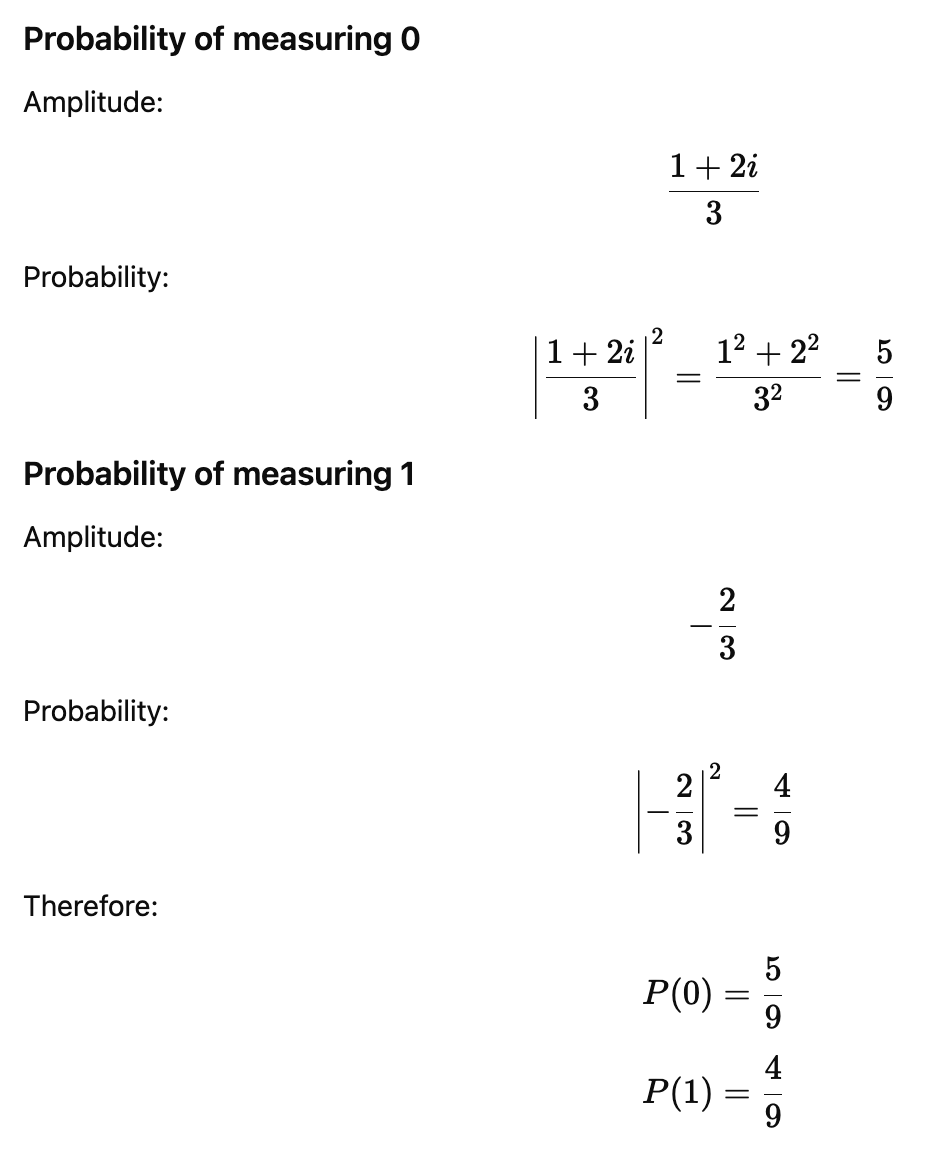

'Measurement Result = 0:'

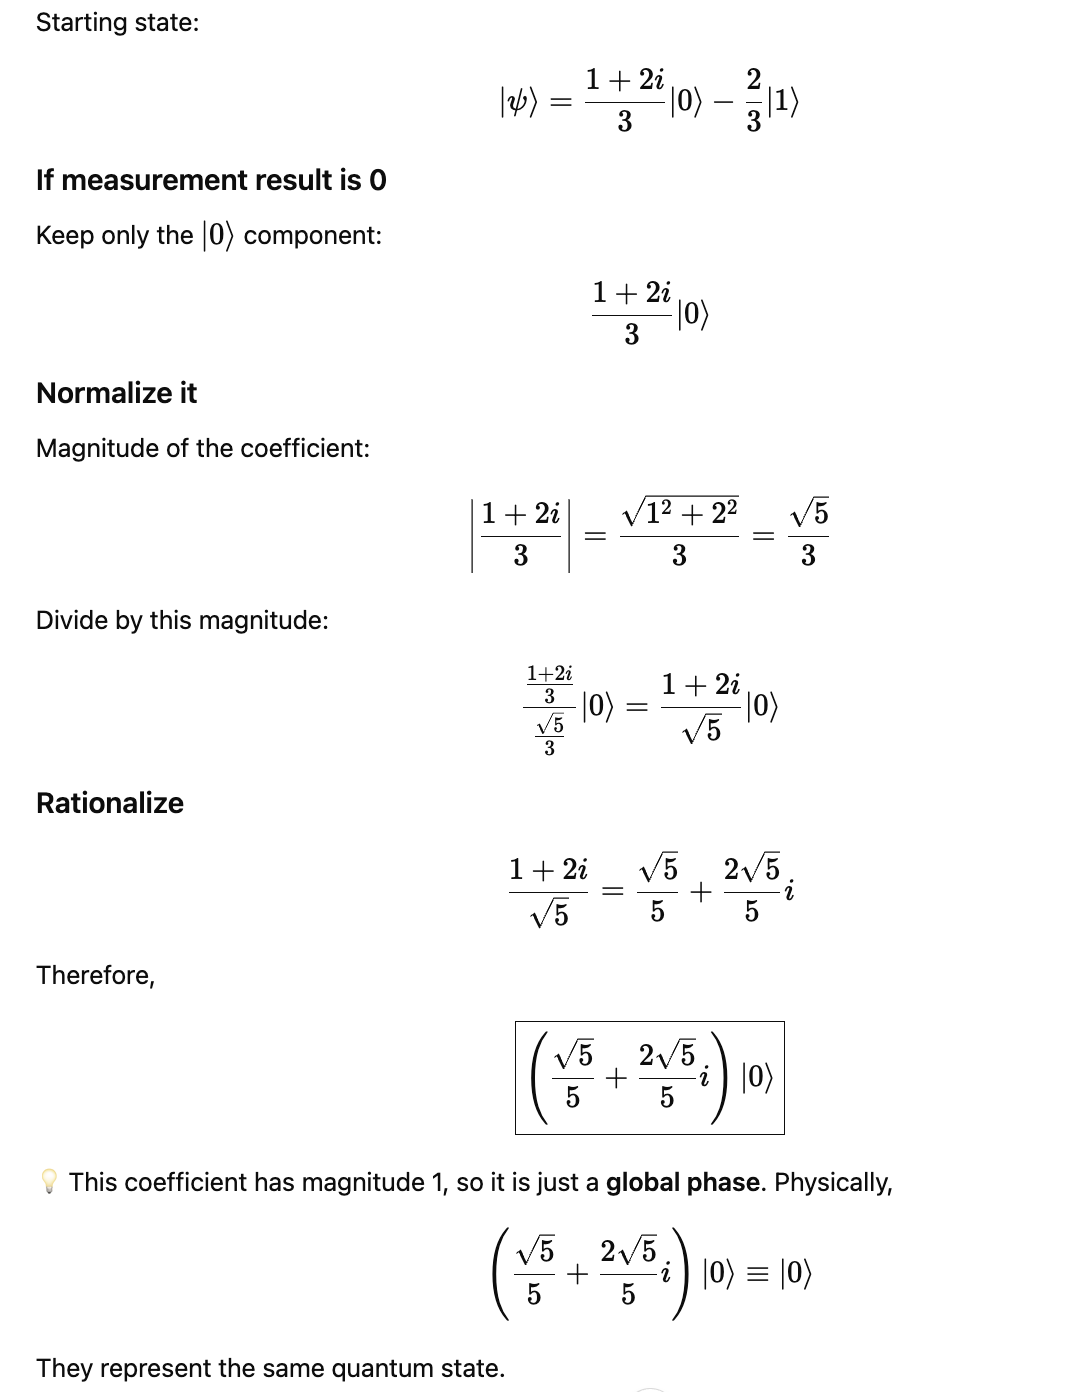

'Measurement Result = 1:'

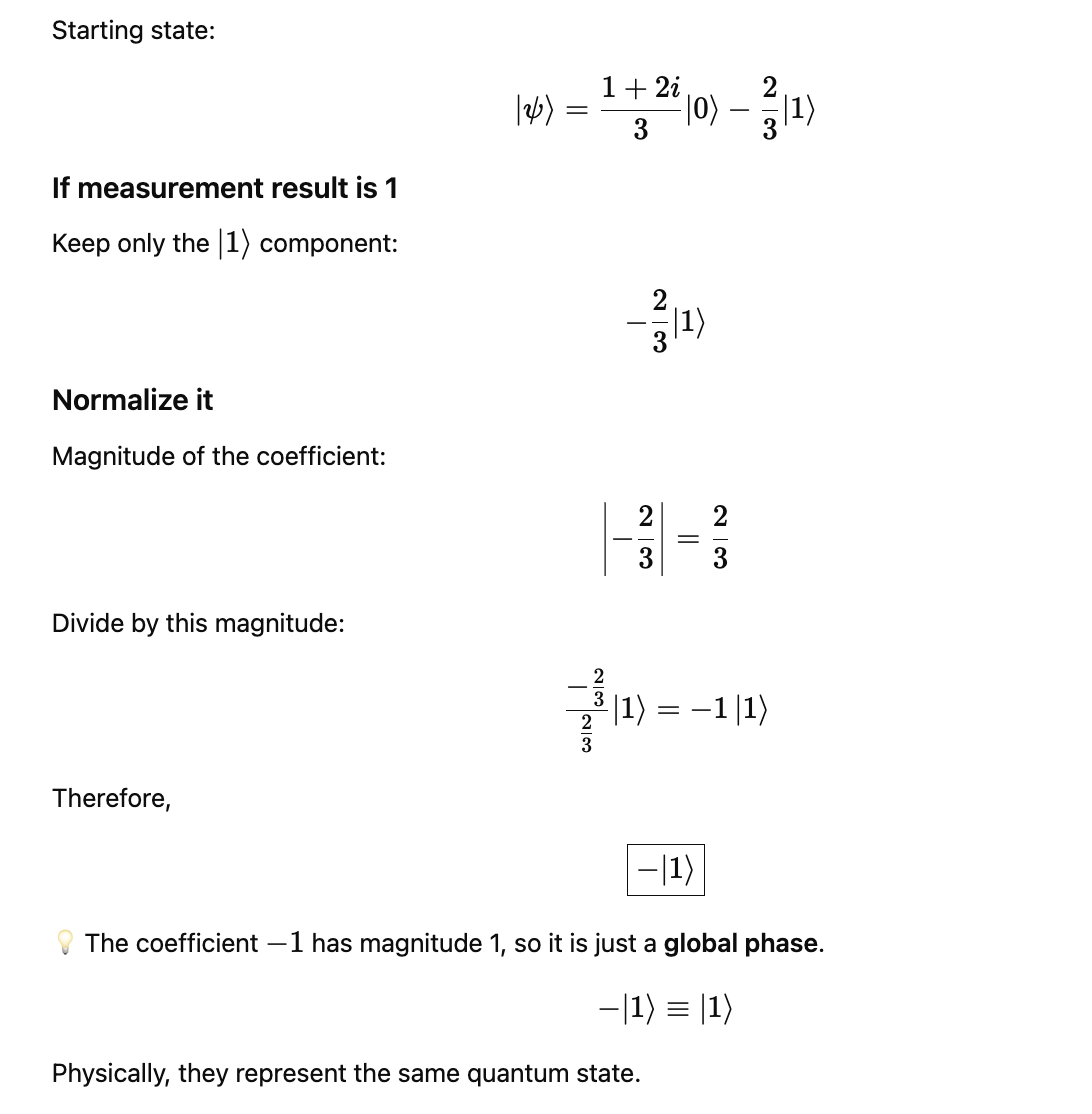

In [26]:
display('Measurement Probability:', Image(filename="images/measurement-probability.png", width=400))
display('Measurement Result = 0:', Image(filename="images/measurement-result-0.png", width=500))
display('Measurement Result = 1:', Image(filename="images/measurement-result-1.png", width=500))

#### More detailed explanation available in excel file

In [ ]:
from IPython.display import HTML

HTML('<a href="docs/post_measurement_state_computation_using_projection_operators.xlsx" download>Download Excel File</a>')

#### Measurement Statistics for 1000 samples

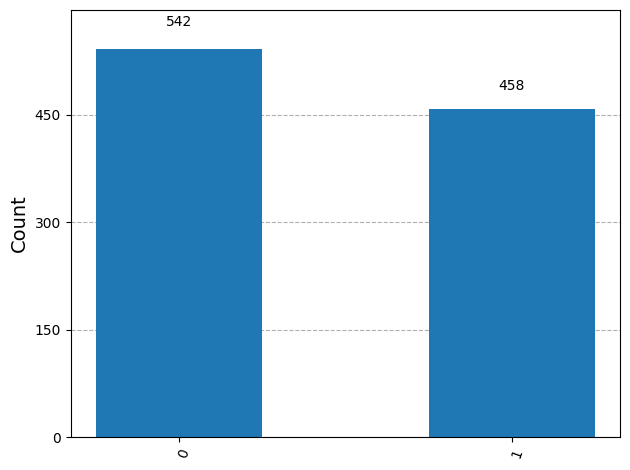

In [19]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

### Perform operations with Operator and Statevector

In [20]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(Y.draw("latex"))
display(H.draw("latex"))
display(S.draw("latex"))
display(T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Apply a unitary operation to a state vector using the evolve method.

In [21]:
v = Statevector([1, 0])
display(v.draw("latex"))

v = v.evolve(H)
display(v.draw("latex"))

v = v.evolve(T)
display(v.draw("latex"))

v = v.evolve(H)
display(v.draw("latex"))

v = v.evolve(S)
display(v.draw("latex"))

v = v.evolve(Y)
display(v.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### A preview of quantum circuits

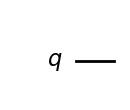

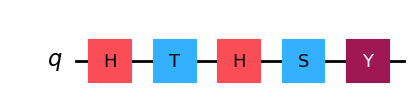

In [22]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)
display(circuit.draw(output="mpl"))

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

In [23]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

In [24]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

#### Simulates an experiment, measured with a standard basis measurement 4000 times

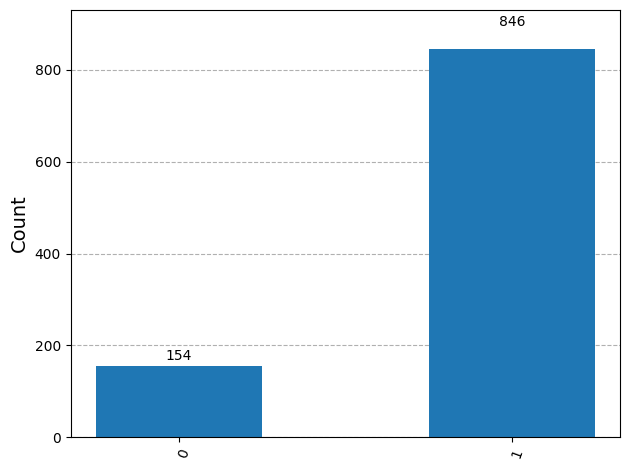

In [25]:
statistics = v.sample_counts(1000)
display(plot_histogram(statistics))